In [8]:
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching as pm

In [124]:
noise_rounds = 1

# 1. Create 9 qubit Shor code circuit
c = stim.Circuit()
# Repitition
c.append('CNOT', [0, 3])    
c.append('CNOT', [0, 6])
# To |+++>, |--->
c.append('H', [0])
c.append('H', [3])
c.append('H', [6])

c.append('CNOT', [0, 1])
c.append('CNOT', [3, 4])
c.append('CNOT', [6, 7])
c.append('CNOT', [0, 2])
c.append('CNOT', [3, 5])
c.append('CNOT', [6, 8])

c.append('TICK')

for i in range(noise_rounds):
    
    c.append("Z_ERROR", [0, 1, 2, 3, 4, 5, 6, 7, 8], 0.01)
    c.append("X_ERROR", [0, 1, 2, 3, 4, 5, 6, 7, 8], 0.02)

    # X stabilizer check
    c.append('H', [9])
    c.append('H', [10])
    c.append("CNOT", [9, 0])
    c.append("CNOT", [9, 1])
    c.append("CNOT", [9, 2])
    c.append("CNOT", [9, 3])
    c.append("CNOT", [9, 4])
    c.append("CNOT", [9, 5])
    c.append("CNOT", [10, 3])
    c.append("CNOT", [10, 4])
    c.append("CNOT", [10, 5])
    c.append("CNOT", [10, 6])
    c.append("CNOT", [10, 7])
    c.append("CNOT", [10, 8])
    c.append("H", [9])
    c.append("H", [10])
    c.append("M", [9])
    c.append("M", [10])
    c.append("R", [9, 10])

    c.append('TICK')

    c.append("CNOT", [0, 9])
    c.append("CNOT", [1, 9])
    c.append("CNOT", [1, 10])
    c.append("CNOT", [2, 10])
    c.append("M", [9, 10])
    c.append("R", [9, 10])

    c.append("TICK")

    c.append("CNOT", [3, 9])
    c.append("CNOT", [4, 9])
    c.append("CNOT", [4, 10])
    c.append("CNOT", [5, 10])
    c.append("M", [9, 10])
    c.append("R", [9, 10])

    c.append("TICK")

    c.append("CNOT", [6, 9])
    c.append("CNOT", [7, 9])
    c.append("CNOT", [7, 10])
    c.append("CNOT", [8, 10])
    c.append("M", [9, 10])
    c.append("R", [9, 10])

print(c.diagram())
sampler = c.compile_sampler()
resultsarr = sampler.sample(shots=1000000)
print(sum(resultsarr))


      /-------\ /--------------------------------------------------------------\ /----------------\ /----------------\ /----------------\
 q0: -@-@-H-@-@-Z_ERROR(0.01)-X_ERROR(0.02)-X------------------------------------@--------------------------------------------------------
      | |   | |                             |                                    |
 q1: -|-|---X-|-Z_ERROR(0.01)-X_ERROR(0.02)-|-X----------------------------------|-@-@----------------------------------------------------
      | |     |                             | |                                  | | |
 q2: -|-|-----X-Z_ERROR(0.01)-X_ERROR(0.02)-|-|-X--------------------------------|-|-|-@--------------------------------------------------
      | |                                   | | |                                | | | |
 q3: -X-|-H-@-@-Z_ERROR(0.01)-X_ERROR(0.02)-|-|-|-X-----X------------------------|-|-|-|------------@-------------------------------------
        |   | |                             | |

In [16]:
noise_rounds = 5

# 1. Create 9 qubit Shor code circuit
c = stim.Circuit()
# Repitition
c.append('CNOT', [0, 3])    
c.append('CNOT', [0, 6])
# To |+++>, |--->
c.append('H', [0])
c.append('H', [3])
c.append('H', [6])

c.append('CNOT', [0, 1])
c.append('CNOT', [3, 4])
c.append('CNOT', [6, 7])
c.append('CNOT', [0, 2])
c.append('CNOT', [3, 5])
c.append('CNOT', [6, 8])

c.append('TICK')

for i in range(noise_rounds):
    
    #c.append("Z_ERROR", [0, 1, 2, 3, 4, 5, 6, 7, 8], 0.01)
    c.append("X_ERROR", [0, 1, 2, 3, 4, 5, 6, 7, 8], 0.02)

    # X stabilizer check
    c.append('MPP', [stim.target_x(0),
                    stim.target_combiner(),
                    stim.target_x(1),
                    stim.target_combiner(),
                    stim.target_x(2),
                    stim.target_combiner(),
                    stim.target_x(3), 
                    stim.target_combiner(),
                    stim.target_x(4),
                    stim.target_combiner(),
                    stim.target_x(5)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_x(3),
                    stim.target_combiner(),
                    stim.target_x(4),
                    stim.target_combiner(),
                    stim.target_x(5),
                    stim.target_combiner(),
                    stim.target_x(6), 
                    stim.target_combiner(),
                    stim.target_x(7),
                    stim.target_combiner(),
                    stim.target_x(8)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_z(0),
                    stim.target_combiner(),
                    stim.target_z(1)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_z(1),
                    stim.target_combiner(),
                    stim.target_z(2)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_z(3),
                    stim.target_combiner(),
                    stim.target_z(4)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_z(4),
                    stim.target_combiner(),
                    stim.target_z(5)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_z(6),
                    stim.target_combiner(),
                    stim.target_z(7)])
    c.append("DETECTOR", [stim.target_rec(-1)])

    c.append('MPP', [stim.target_z(7),
                    stim.target_combiner(),
                    stim.target_z(8)])
    c.append("DETECTOR", [stim.target_rec(-1)])
    

c.append('MPP', [stim.target_x(0), 
                stim.target_combiner(),
                stim.target_x(1),
                stim.target_combiner(),
                stim.target_x(2)], 0)
c.append('OBSERVABLE_INCLUDE', [stim.target_rec(-1)], 0)

print(c.diagram())
#sampler = c.compile_sampler()
sampler = c.compile_detector_sampler()
resultsarr = sampler.sample(shots=1000000)
print(sum(resultsarr))


     /-------\ /-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------\
q0: -@-@-H-@-@-X_ERROR(0.02)-MPP[X]:rec[0]-DETE

In [17]:
sampler = c.compile_detector_sampler()
detection_events, observable_flips = sampler.sample(shots=1000000, separate_observables=True)
print(detection_events)
print(np.sum(observable_flips))


[[False False False ... False False False]
 [False False False ... False False  True]
 [False False False ... False False False]
 ...
 [False False False ...  True False False]
 [False False False ... False False False]
 [False False False ... False False False]]
0


In [18]:
print(np.sum(detection_events[:,7]))

39122


In [19]:


def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pm.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

print(count_logical_errors(c, 1000000))

ValueError: Failed to decompose errors into graphlike components with at most two symptoms.
The error component that failed to decompose is 'D2, D3, D10, D11, D18, D19, D26, D27, D34, D35'.

In Python, you can ignore this error by passing `ignore_decomposition_failures=True` to `stim.Circuit.detector_error_model(...)`.
From the command line, you can ignore this error by passing the flag `--ignore_decomposition_failures` to `stim analyze_errors`.

In [98]:
c = stim.Circuit()

c.append("X", [1])
c.append("CNOT", [0, 1])
c.append("M", [0])
c.append("M", [1])
print(c.diagram())
sampler = c.compile_sampler()
resultsarr = sampler.sample(shots=100000)
print(sum(resultsarr))

q0: ---@-M:rec[0]-
       |
q1: -X-X-M:rec[1]-
[     0 100000]


In [72]:
c = stim.Circuit()
c.append('H', [0])
c.append('M', [0])
c.append('R', [0])
c.append('X', [0])
c.append('M', [0])
print(c.diagram())
sampler = c.compile_sampler()
resultsarr = sampler.sample(shots=100000)
print(sum(resultsarr))


q0: -H-M:rec[0]-R-X-M:rec[1]-
[ 50034 100000]


In [ ]:
def build_shor_code_circuit_stim(p, error_gate='X'):

    lines = []
    # prepare 3 GHZ blocks
    lines.append("R 0 1 2 3 4 5 6 7 8")
    lines.append("H 0 3 6")
    lines.append("CNOT 0 1 0 2 3 4 3 5 6 7 6 8")

    # insert error gates
    if error_gate == 'X':
        lines.append(f"X_ERROR({p}) 0 1 2 3 4 5 6 7 8")
    else:
        lines.append(f"Z_ERROR({p}) 0 1 2 3 4 5 6 7 8")

    # syndrome checks and associated detectors
    if error_gate == 'X':
        # X noise anti-commutes with ZZ checks within blocks
        for zz in ["Z0*Z1", "Z1*Z2", "Z3*Z4", "Z4*Z5", "Z6*Z7", "Z7*Z8"]:
            lines.append(f"MPP {zz}")
            lines.append("DETECTOR rec[-1]")
        # XX checks across blocks
        for xx in ["X0*X1*X2*X3*X4*X5", "X3*X4*X5*X6*X7*X8"]:
            lines.append(f"MPP {xx}")
            lines.append("DETECTOR rec[-1]")
        # Logical Z_L at the end (to be used as observable)
        lines.append("MPP Z0*Z3*Z6")
        lines.append("OBSERVABLE_INCLUDE(0) rec[-1]")
    else: # error gate is Z
        # Z noise anti-commutes with XX checks across blocks
        for xx in ["X0*X1*X2*X3*X4*X5", "X3*X4*X5*X6*X7*X8"]:
            lines.append(f"MPP {xx}")
            lines.append("DETECTOR rec[-1]")
        # ZZ checks within blocks
        for zz in ["Z0*Z1", "Z1*Z2", "Z3*Z4", "Z4*Z5", "Z6*Z7", "Z7*Z8"]:
            lines.append(f"MPP {zz}")
            lines.append("DETECTOR rec[-1]")
        # Logical X_L at the end (to be used as observable)
        lines.append("MPP X0*X1*X2*X3*X4*X5*X6*X7*X8")
        lines.append("OBSERVABLE_INCLUDE(0) rec[-1]")

    return stim.Circuit("\n".join(lines))

def get_logical_error_probability_for_shor_code(p, n_shots=50_000, error_gate='X', verbose = False):
    circuit = build_shor_code_circuit_stim(p, error_gate=error_gate)
    if verbose:
        display(circuit.diagram('timeline-svg'))

    # same workflow as in rep codes: 
    # sample shots from the circuit to get detector and logical observable flips
    # create a DEM from the circuit to use for the decoder
    # determine if the decoder can use the detector flips to predict observable flips
    ds = circuit.compile_detector_sampler()
    D, L = ds.sample(n_shots, separate_observables=True)
    dem = circuit.detector_error_model(decompose_errors=True)
    m = pm.Matching.from_detector_error_model(dem)
    pred = m.decode_batch(D)
    total_logical_error_count = sum(pred[:, 0] != L[:, 0])
    return total_logical_error_count / n_shotsx

def get_logical_error_probability_stim_shor(ps, n_shots=50_000, error_gate='X'):
    p_Ls = []
    for j, p in enumerate(ps):
        if j == 0:
            p_Ls.append(get_logical_error_probability_for_shor_code(p, n_shots=n_shots, error_gate=error_gate, verbose = True))
        else:
            p_Ls.append(get_logical_error_probability_for_shor_code(p, n_shots=n_shots, error_gate=error_gate, verbose = False))          
    return p_Ls

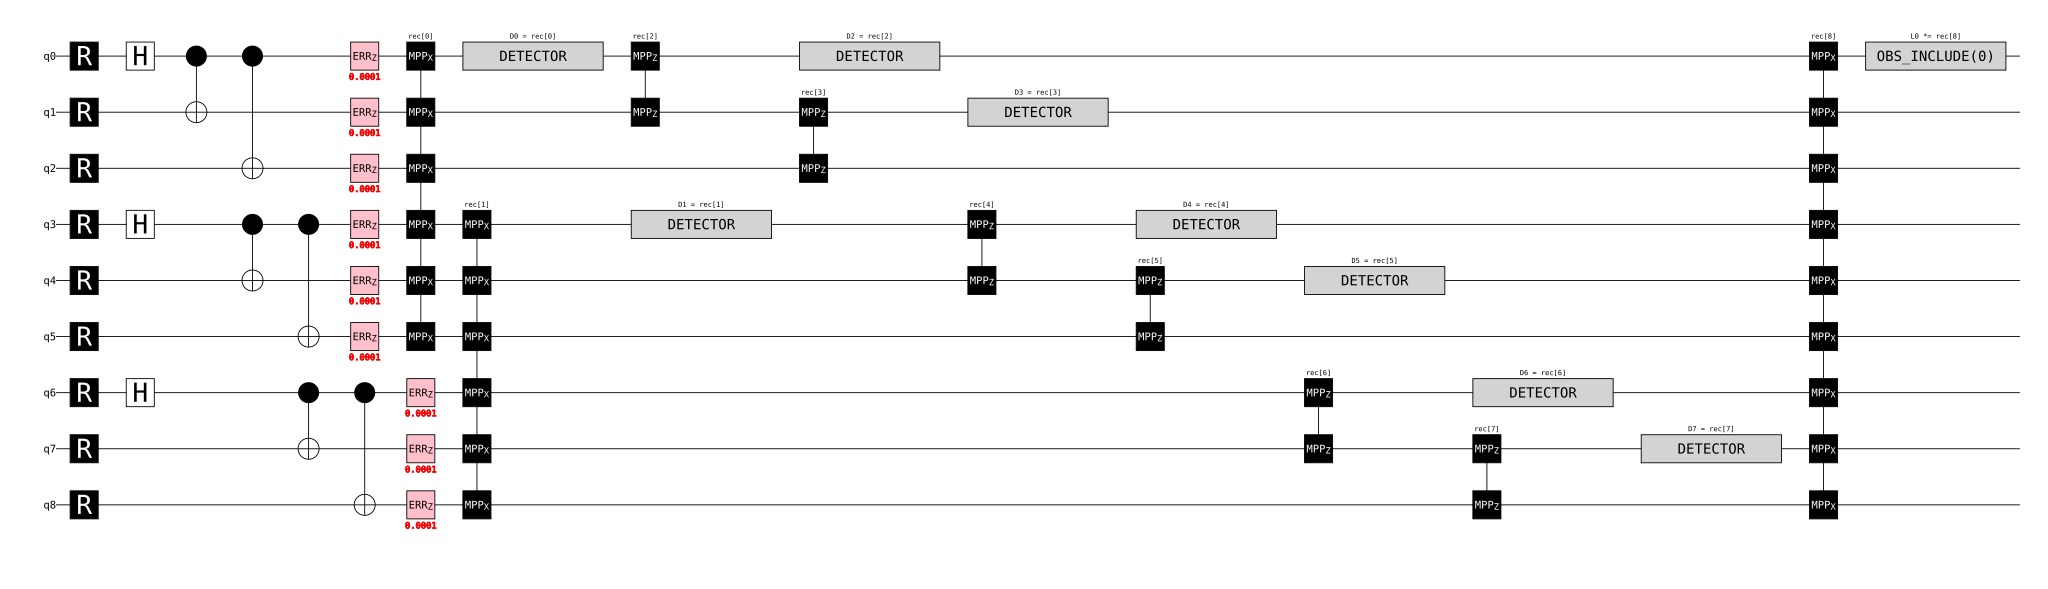

In [3]:
ps = np.logspace(-4, -0.5, 20)
n_shots = 1000000

p_Ls = get_logical_error_probability_stim_shor(ps = ps, n_shots = n_shots, error_gate = 'Z')

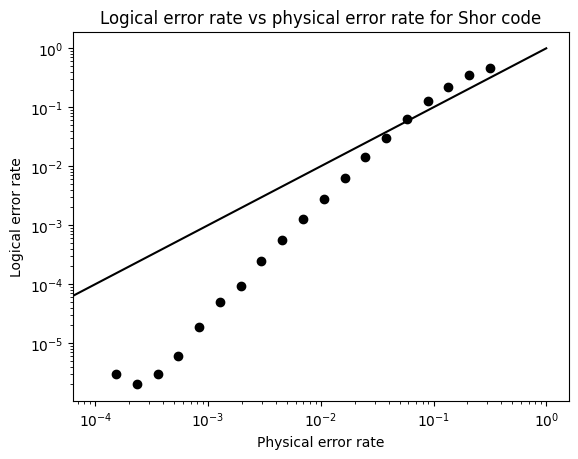

In [4]:
plt.plot(ps, p_Ls, 'o', color = 'black')
plt.plot([0, 1], [0, 1], color = 'black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical error rate')
plt.ylabel('Logical error rate')
plt.title('Logical error rate vs physical error rate for Shor code')
plt.show()